In [14]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram, plot_state_qsphere
from qiskit_aer import AerSimulator

In [2]:
%matplotlib inline

# Classical Way

In [3]:
mylist = [5,4,6,9,1,2,3,7,8,0]

In [4]:
def oracle(number):
    winningNumber = 8
    if number == winningNumber:
        return True
    return False

In [5]:
for index, number in enumerate(mylist):
    if oracle(number):
        print(f"winning number index: {index}")
        print(f"execution count: {index + 1}")
        break

winning number index: 8
execution count: 9


# Quantum Way

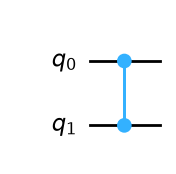

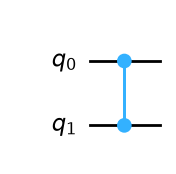

In [6]:
oracleCircuit = QuantumCircuit(2, name="oracleCircuit")
oracleCircuit.cz(0,1)
oracleCircuit.draw(output="mpl")

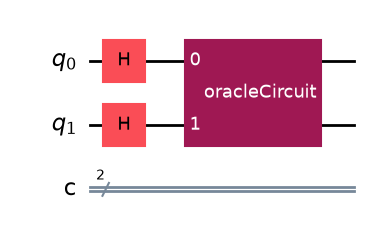

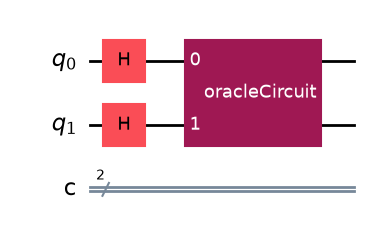

In [8]:
mainCircuit = QuantumCircuit(2,2)
mainCircuit.h([0,1])
mainCircuit.append(oracleCircuit.to_gate(), [0,1])
mainCircuit.draw(output="mpl")

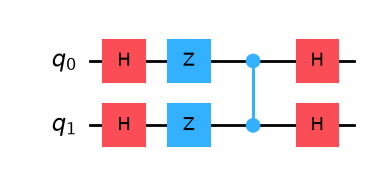

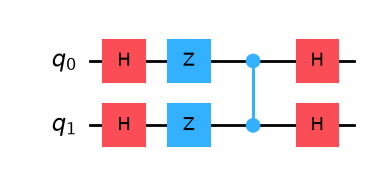

In [11]:
reflectionCircuit = QuantumCircuit(2, name="reflectionCircuit")
reflectionCircuit.h([0,1])
reflectionCircuit.z([0,1])
reflectionCircuit.cz(0,1)
reflectionCircuit.h([0,1])
reflectionCircuit.to_gate()
reflectionCircuit.draw(output="mpl")

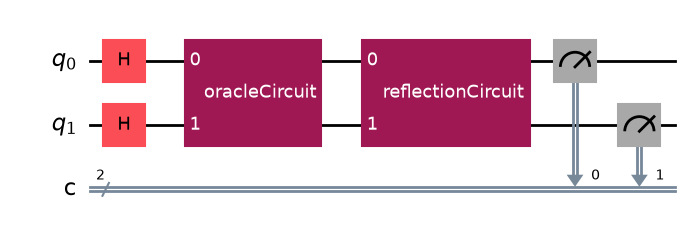

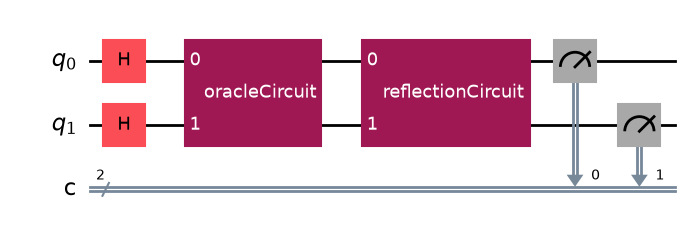

In [12]:
mainCircuit.append(reflectionCircuit, [0,1])
mainCircuit.measure([0,1], [0,1])
mainCircuit.draw(output="mpl")

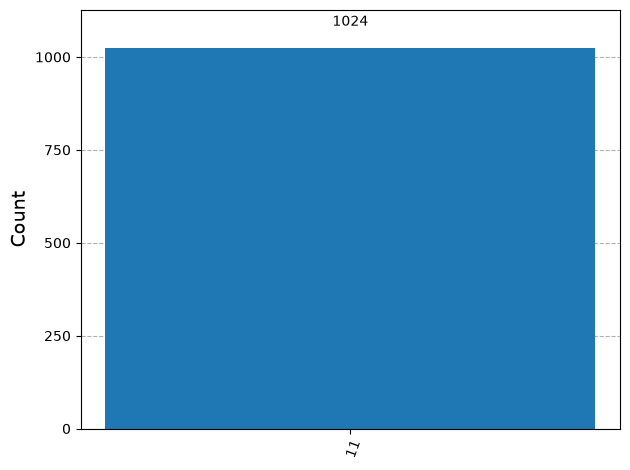

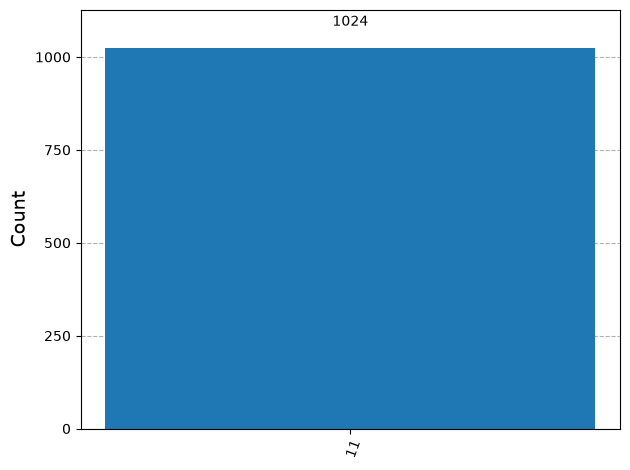

In [13]:
simulator = AerSimulator()
compiled = transpile(mainCircuit, simulator)
result = simulator.run([compiled], shots = 1024).result()
counts = result.get_counts()
plot_histogram([counts])